<h1>Regularisation</h1>

It minimises overfitting (analysis/model fitting too closely to a particular dataset) and is executed during the model fitting step. If a model is able to accurately make predictions on one set of data but poorly on unseen/different datas we have overfitting. 

<h2>Overfitting Signs</h2>
 - Fits training data well but performs significantly worse on test data
 - It has more parameters than needed, high model complexity
 - It might be fitting for features that are multi-collinear 
 - Fitting noise in the data treating it as feature.

It is also considered an embeded feature selection method because it is done when parameters of the model are being calculated. 

Regularisation helps makes models more generalisable. 

<h2>Demonstrating Overfitting</h2>

In [29]:
import pandas as pd

df = pd.read_csv("student_math.csv")

y = df["Final_Grade"]
X = df.drop(columns=["Final_Grade"])


In [30]:
num_features = len(X.columns)
print(f"Number of Features: {num_features}")

Number of Features: 41


Large number of features - fitting a model on this many features without EDA and feature selection suggests the model with overfit the data. 

To demonstrate overfitting I will first fit a model with the full feature set and compare it to a model with fewer features

In [31]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model on training data
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

# MSE on training Data
import numpy as np

pred_train = linear_regression.predict(X_train)
MSE_train = np.mean((pred_train - y_train)**2)
print(f"Training set mean squared error: {MSE_train}")

# MSE on test data
pred_test = linear_regression.predict(X_test)
MSE_test = np.mean((pred_test - y_test)**2)
print(f"Test set mean squared error: {MSE_test}")

predictors = X.columns
coef = pd.Series(linear_regression.coef_,predictors).sort_values()

Training set mean squared error: 2.7067343321070942
Test set mean squared error: 4.993008659924369


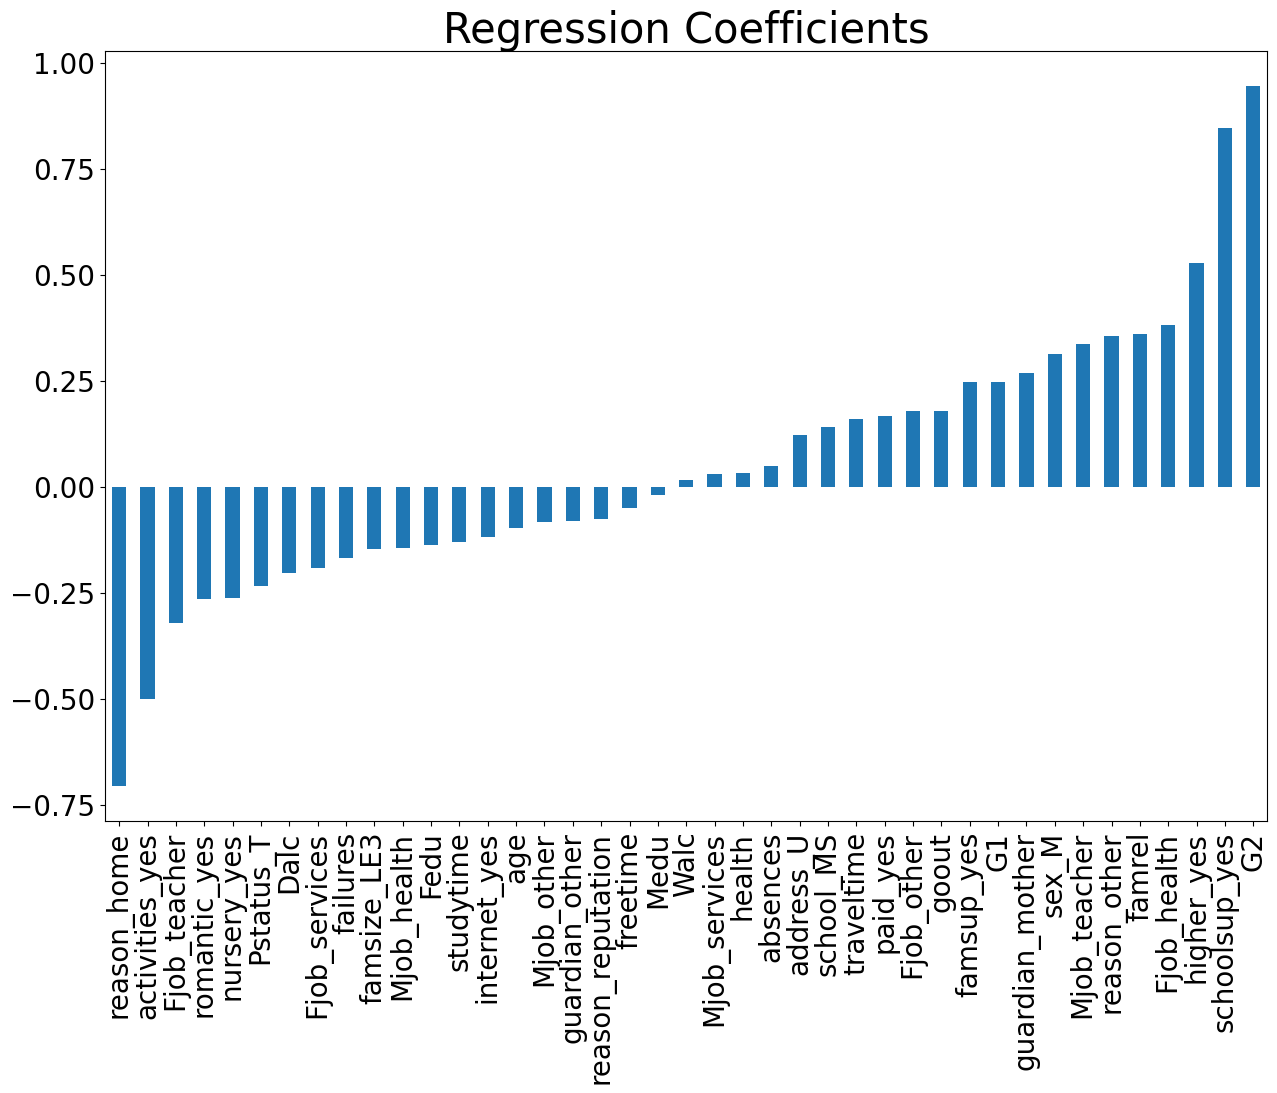

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
coef.plot(kind='bar', fontsize = 20)
plt.title ("Regression Coefficients", fontsize = 30)
plt.show()

In linear regression, the loss function (MSE) is minimised by OLS or gradient descent on larger datasets but this does not always generalise well. Regularisation can help this as seen below.

[46.58140486 27.46174293]


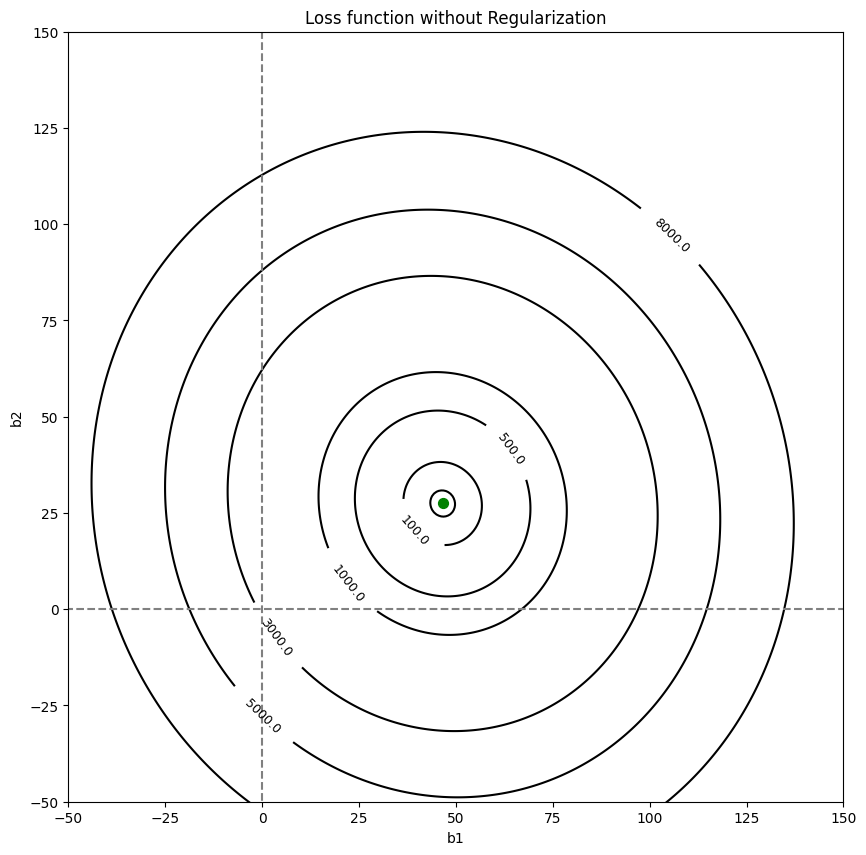

In [33]:
from sklearn import datasets

# Generating a sample regression model
data, y, coefficients = datasets.make_regression(n_samples = 395, n_features = 2, coef = True, random_state = 23)
x1 = data[:,0]
x2 = data[:,1]

# Print the coefficients
print(coefficients)

# Loss Function
def loss_function(b1,b2,y,x1,x2):
    error = y - (b1*x1 + b2*x2)
    loss = np.mean(error**2)
    return loss

# 3. Plot loss function for data

def plot_loss_function(b1,b2,y,x1,x2):
    loss = np.asarray([[loss_function(i,j,y,x1,x2) for i in b1] for j in b2])
    fig, ax = plt.subplots(figsize = (10,10))
    CS = ax.contour(b1, b2, loss, levels = [0,10, 100, 500, 1000, 3000, 5000, 8000], colors='k')
    ax.clabel(CS, fontsize=9,fmt='%1.1f', inline=True)
    ax.set_title('Loss function without Regularization')
    plt.plot([0,0,0,0,0], [-150,0,10,50,150], color = 'grey', linestyle = 'dashed')
    plt.plot([-150,0,10,50,150],[0,0,0,0,0], color = 'grey', linestyle = 'dashed')
    plt.xlim(-50,150)
    plt.ylim(-50,150)
    plt.xlabel('b1')
    plt.ylabel('b2')
    return CS

b1 = np.linspace(-150, 150, 501)
b2 = np.linspace(-150, 150, 501)
contour_plot = plot_loss_function(b1,b2,y,x1,x2)


# Plot the best fit coefficients
best_fit_b1 = coefficients[0]
best_fit_b2 = coefficients[1]
plt.scatter(best_fit_b1, best_fit_b2, s = 50, color = 'green')
plt.show()

Each ellipse in this plot represents the points where the loss function has the same value. The larger the ellipse, the higher the value of loss for all the points (b1,b2) that fall on the ellipse, as we can see from the labels on the contours.

Following this logic, the center of this set of concentric ellipses should represent the minimum value of the loss function and the value of the coefficients (b1,b2) at this point should be the solution of the regression problem and represent the best fit for our data (75,23).

<h2>Regularisation Term</h2>

Adds a penalty to the loss function when a model overfits. The most common methods for this a Lasso and Ridge regularisation. The penalty is applied by limiting how large a coefficient can get thus reducing the predictive influence. The penalty term is multiplied by a factor and added to the old loss function as below:

***New Loss Function = Old Loss Function +     $\alpha$ Penalty Term***


The penalty term for Lasso regularisation is |b1| + |b2| + ... + |bn|
The penalty term for ridge regularisation is b1^2 + b2^2 + ... + bn^2

The added term means the value of true loss increases, thus meaning the MSE on the training data for example increases - this is what is required. 

<h1>Lasso Regularisation</h1>

### L1 Loss Function (Mean Absolute Error - MAE)

The L1 loss function, also known as Mean Absolute Error (MAE), quantifies the average absolute difference between the predicted values and the true target values in a dataset. It is defined as:

$$ L_1 = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i| $$

Where:
-   $N$ is the number of data points.
-   $y_i$ represents the actual (true) value for the $i$-th data point.
-   $\hat{y}_i$ represents the predicted value for the $i$-th data point.
-   $| \cdot |$ denotes the absolute value.

**Key Characteristics:**

-   **Robust to Outliers:** Unlike L2 loss (Mean Squared Error), L1 loss is less sensitive to outliers because it penalizes errors linearly, rather than quadratically. This means large errors do not have an excessively disproportionate impact on the total loss.
-   **Sparse Solutions (in Regularisation):** When used as a regularisation term (L1 regularization or Lasso regression), it can encourage sparsity in model parameters, effectively driving some coefficients to zero and performing feature selection.
-   **Non-differentiable at Zero:** The absolute value function is not differentiable at zero, which can pose challenges for optimization algorithms that rely on gradients, though subgradients are often used in practice.

**Use Cases:**

L1 loss is frequently used in scenarios where:
-   The presence of outliers in the data is a concern.
-   Feature selection or model sparsity is desired (when used as a regularisation term).
-   Interpretability of the error is important, as it represents the average magnitude of the errors.

To demonstrate L1 regularisation I will use the same student data.

In [34]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

l1_pred_train = lasso.predict(X_train)
l1_mse_train = np.mean((l1_pred_train - y_train)**2)

l1_pred_test = lasso.predict(X_test)
l1_mse_test = np.mean((l1_pred_test - y_test)**2)

print("Lasso (L1) Training Error: ", l1_mse_train)
print("Lasso (L1) Test Error: ", l1_mse_test)

Lasso (L1) Training Error:  3.1203824682878474
Lasso (L1) Test Error:  4.22903040878447


Training error increased but test error has decreased.

<Axes: title={'center': 'Regression Coefficients with Lasso (L1) Regularisation'}>

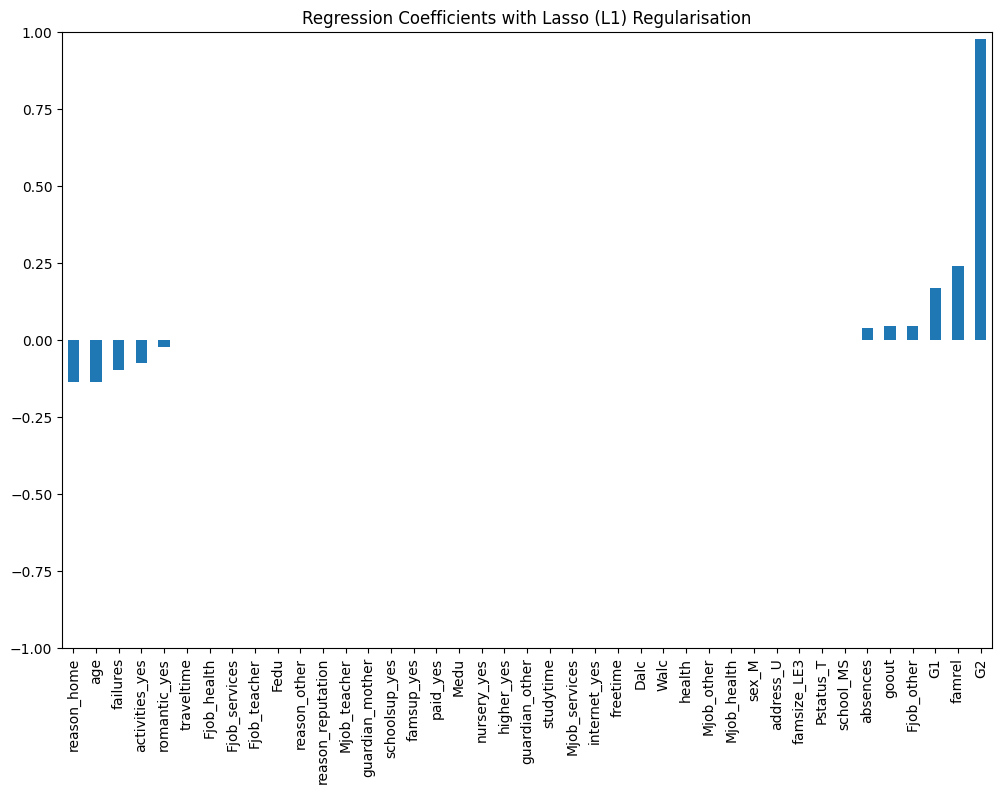

In [35]:
predictors = X.columns
coef = pd.Series(lasso.coef_,predictors).sort_values()
plt.figure(figsize = (12,8))
plt.ylim(-1.0,1.0)
coef.plot(kind='bar', title='Regression Coefficients with Lasso (L1) Regularisation')

Significant amount of features have been removed by their coefficients being set to zero. Using different alpha values will yield different results.

<h2>Ridge Regularisation</h2>

L(y, ŷ) = (1/N) * Σ(y_i - ŷ_i)²

The difference is that instead of a diamond area for constraining the coefficients in a circle of radius s. The aim is similar, minimise the old loss function with the restrictions for the coefficients. Coefficient values can never be zero for ridge regularisation. 

In [36]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)

l2_pred_train = ridge.predict(X_train)
l2_mse_train = np.mean((l2_pred_train - y_train)**2)
print("Ridge (L2) Training MSE", l2_mse_train)

l2_pred_test = ridge.predict(X_test)
ls_mse_test = np.mean((l2_pred_test - y_test)**2)
print("Ridge (L2) Test MSE" , ls_mse_test)

Ridge (L2) Training MSE 2.9145877408546785
Ridge (L2) Test MSE 4.362837388697656


<Axes: title={'center': 'Regression Coefficients with Ridge (L2) Regularization'}>

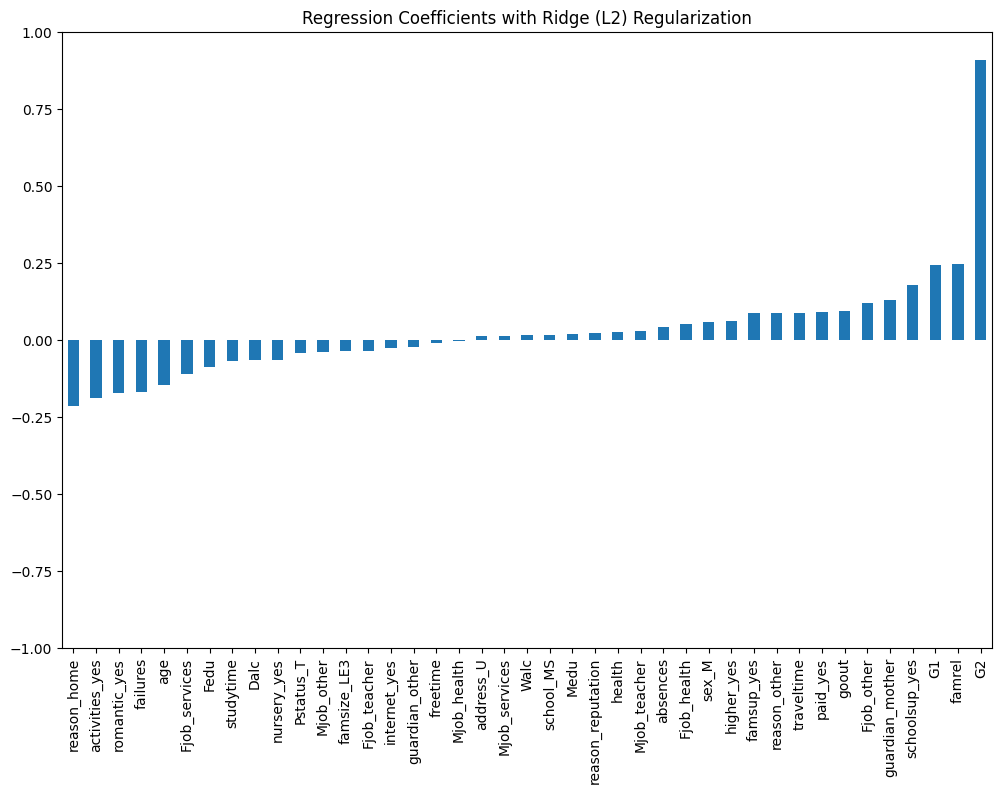

In [37]:
predictors = X.columns
coef = pd.Series(ridge.coef_,predictors).sort_values()
plt.figure(figsize = (12,8))
plt.ylim(-1.0,1.0)
coef.plot(kind='bar', title='Regression Coefficients with Ridge (L2) Regularization')

<h1>Hyperparameter Tuning</h1>

In this case $\alpha$ is a hyper parameter - it is not learned in the model fitting instead chosen to control the learning process. 

$\alpha$ represents the size of the area we want to confine the constraint to and thus the size of the coefficients. $\alpha$ is inversely proportional to the size of the coefficients. 

<h1>Bias Vairance Tradeoff</h1>
Adding a regularisation term introduces bias, confining the values of the coefficients. Greater alpha, smaller coefficients and vice-versa. It needs to be selected appropriately such that underfitting is not introduced through extra variance in the model. Minimising bias, increases variance - this is the Bias Variance Tradeoff. By taking some data and using it as the validation set (not part of train test split) there is data available for hyper parameter tuning. 




<h1>Tuning model hyperparameter</h1>
alpha being 0 is equivalent to there being no regularisation and when alpha is too large we introduce too bias. 

Plotting multiple different values for alpha and against the Training and Test MSE. However it is possible this value is different for a different train test split. <code>GridSearchCV</code> from scikit-learn can be used to find the optimal value. 

<code>GridSearchCV</code> uses a k-fold cross validation method to search for the optimal hyperparameter. It splits the train test data k times to ensure conclusions are representative of the data not a sample. 

In [38]:
df = pd.read_csv("student_math.csv")

y = df["Final_Grade"]
X = df.drop(columns=["Final_Grade"])

alpha_array = np.logspace(-6, 0, 100) #100 alpha array values

tuned_parameters = [{"alpha": alpha_array}]

from sklearn.model_selection import GridSearchCV
grid_search_cv = GridSearchCV(estimator=Lasso(), param_grid=tuned_parameters, scoring='neg_mean_squared_error', cv=5, return_train_score=True)
grid_search_cv.fit(X, y)

,estimator,Lasso()
,param_grid,[{'alpha': array([1.0000...00000000e+00])}]
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,0.12328467394420659


In [39]:
test_errors = grid_search_cv.cv_results_['mean_test_score']
train_errors = grid_search_cv.cv_results_['mean_train_score']

print(f"Test Scores: {grid_search_cv.cv_results_['mean_test_score']}")
print(f"Train Scores: {grid_search_cv.cv_results_['mean_train_score']}")

Test Scores: [-4.28856135 -4.28855792 -4.28855399 -4.28854946 -4.28854426 -4.28853828
 -4.28853141 -4.2885235  -4.28851441 -4.28850395 -4.28849194 -4.28847812
 -4.28846224 -4.28844398 -4.28842298 -4.28839884 -4.28837107 -4.28833919
 -4.28830253 -4.28826036 -4.28821188 -4.28815614 -4.28809206 -4.28801836
 -4.28793368 -4.28783637 -4.28772448 -4.28759591 -4.28744801 -4.28727811
 -4.287083   -4.28685862 -4.28660103 -4.28630466 -4.28596433 -4.28557315
 -4.28512389 -4.28460809 -4.28401541 -4.28333545 -4.28255504 -4.28165935
 -4.28063213 -4.27945451 -4.2781063  -4.27656046 -4.2747431  -4.27265513
 -4.27026902 -4.26753302 -4.26445063 -4.261041   -4.25744031 -4.25332732
 -4.24869083 -4.24329449 -4.23737151 -4.23058693 -4.22288419 -4.21403715
 -4.20376248 -4.19234366 -4.17963395 -4.16573262 -4.15042878 -4.13357169
 -4.11634634 -4.09741504 -4.07528078 -4.05056661 -4.02383496 -3.99247641
 -3.96089344 -3.92961633 -3.90245488 -3.87506251 -3.85493811 -3.83730136
 -3.81784042 -3.79813193 -3.7788522  -

In [40]:
print(grid_search_cv.best_params_, grid_search_cv.best_score_)

{'alpha': 0.12328467394420659} -3.743294901559114


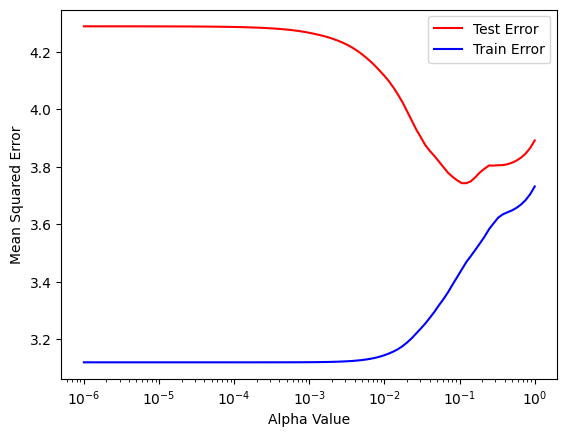

In [41]:
plt.xscale("log")
plt.plot(alpha_array, -test_errors, label="Test Error", color="red")
plt.plot(alpha_array, -train_errors, label="Train Error", color="blue")
plt.xlabel("Alpha Value")
plt.ylabel("Mean Squared Error")
plt.legend()

<h1>Regularisation with Logistic Regression</h1>

Default in scikit-lean logistic regression is already regularised using L2 and alpha set to 100. <code>LogisticRegression()</code> is different to <code>Lasso(), Ridge</code> in the sense that it has input parameter <code>c</code> which is the inverse of alpha. This is important to note when setting up the GridSearchCv.  

In [42]:
from sklearn.linear_model import LogisticRegression

# Logistic regression with no regularisation.
logistic_regression_no_regularisation  = LogisticRegression(penalty='none')

# Logistic regression with L1 regularisation 
logistic_regression_L1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.05) # liblinear has to be used for L1 to work

# Logistic regression with L2 regularisation 
logistic_regression_L2 = LogisticRegression(C=.05)

# Logistic regression with elastic net regularisation
logistic_regression_elastic_net = LogisticRegression(penalty='elasticnet', solver='saga', C=0.05, l1_ratio=0.5)

In [43]:
# Tuning hyperparameter C using GridsearchCv
C_array = np.logspace(-2, 1, 100)
tuning_C = [{'C': C_array}]
grid_search_cv_c = GridSearchCV(logistic_regression_L1, param_grid=tuning_C, scoring='accuracy', cv=5, return_train_score=True)
grid_search_cv_c.fit(X, y)

print("Best parameters", grid_search_cv_c.best_params_)
print("Best Score", grid_search_cv_c.best_score_)

C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for

Best parameters {'C': 0.07054802310718646}
Best Score 0.33164556962025316


C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
